# Flow of a Darcy fluid injected and extracted in a porous rectangle

<!-- $$
\mathbb{S}_{\mathbf{u},p}
\begin{cases}
\Omega = [-L_x/2, L_x/2] \times [-L_y/2, L_y/2] \\
\mathsf{K}=\begin{cases}
K^-(x,y)\mathsf{I} & (x/a)^2 + (y/b)^2 < 1 \\
K^+(x,y)\mathsf{I} & \text{otherwise} 
\end{cases} & \text{lens of low permeability}  \\
\mu = 1 & \text{constant viscosity} \\
u_{\text{E}}(x,y=\pm L_y/2) = 0 & \text{no-penetration on upper and lower boundaries} \\
p_{\text{N}}(x=-L_x/2,y) = p_{\text{in}} & \text{high-pressure left boundary} \\
p_{\text{N}}(x=L_x/2,y) = 0 & \text{low-pressure left boundary} \\
\end{cases}
$$ -->

In [ ]:
# %load_ext autoreload
# %autoreload 2

import numpy as np
from lucifex.mesh import rectangle_mesh, mesh_boundary
from lucifex.fem import Function, Constant
from lucifex.solver import bvp, BoundaryConditions, OptionsPETSc
from lucifex.utils.fenicsx_utils import extract_component_functions
from lucifex.viz import plot_colormap, plot_streamlines, plot_quiver, save_figure
from lucifex.pde.darcy import darcy

Lx = 5.0
Ly = 1.0
Nx = 30
Ny = 30
mesh = rectangle_mesh(Lx, Ly, Nx, Ny, cell='right')
boundary = mesh_boundary(
    mesh, 
    {
        "left": lambda x: x[0],
        "right": lambda x: x[0] - Lx,
        "lower": lambda x: x[1],
        "upper": lambda x: x[1] - Ly,
    },
)

mu = Constant(mesh, 1.0, 'mu')

u_deg = 1
u_elem = ('BDM', u_deg)
p_elem = ('DP', u_deg - 1)
u_p_elem = [u_elem, p_elem]


xIn = 0.25 * Lx
xOut = 0.75 * Lx
uIn_max = 1.0
uStd = 0.1 * Lx
uIn = lambda x: (
    uIn_max * np.exp(-((xIn - x[0]) / uStd)**2) 
    - uIn_max * np.exp(-((xOut - x[0]) / uStd)**2)
)
u_bcs = BoundaryConditions(
    ('essential', boundary['left', 'right', 'upper'], (0.0, 0.0), 0),
    ('essential', boundary['lower'], (0, uIn), 0),
)

petsc = OptionsPETSc(
    ksp_type='preonly', 
    pc_type='lu', 
    pc_factor_mat_solver_type='mumps',
)

Nk = 10
dk = 0.9
eps = 0.1
kStd = 0.05 * Ly
k = Function(
    (mesh, 'P', 1), 
    lambda x: (1 + eps * np.sin(Nk *  np.pi * x[0] / Lx)) * (1.0 - 0.5 * np.exp(-((Ly/2 - x[1]) / kStd)**2)),
    name='k',
)

upMixed = Function((mesh, u_p_elem), name="upMixed")
upMixed_solver = bvp(darcy, bcs=u_bcs, petsc=petsc)(
    upMixed, k, mu, add_zero=(True, True), blocked=False, 
)

upBlocked = Function((mesh, u_p_elem), name="upBlocked")
upBlocked_solver = bvp(darcy, bcs=u_bcs, petsc=petsc)(
    upBlocked, k, mu, add_zero=(True, True), blocked=True, 
)

: 

In [11]:
from lucifex.utils.fenicsx_utils import extract_linear_form, extract_bilinear_form
from lucifex.solver.petsc import create_metaform, view_petsc_vector
import dolfinx

bf = darcy(upBlocked, k, mu, blocked=True, add_zero=(True, True))
bfl = extract_linear_form(bf)
bfa = extract_bilinear_form(bf)

# print(bfl.forms)
# print(bfl.is_vector_like)

F_div, F_velocity, F_pressure, F_src, F_force = upMixed_solver.forms

b_vec = dolfinx.fem.petsc.assemble_vector_block(
    create_metaform(
        [F_force, F_src],
    ), 
    create_metaform(
        [[F_velocity, F_pressure],
        [F_div, None]],
    ), 
    bcs=upMixed_solver._bcs,
)

max(view_petsc_vector(b_vec, 'dense'))

0.16513057927690686

In [13]:
upMixed_solver.solve()
upBlocked_solver.solve()

In [5]:
# max(upMixed_solver.get_vector('dense')), max(upBlocked_solver.get_vector('dense'))

np.min(upMixed_solver.get_matrix('dense')), np.min(upBlocked_solver.get_matrix('dense'))

(-2.558520868397105, -2.558520868397105)

In [6]:
print(upMixed_solver.forms[-1])

{ ([v_0[0], v_0[1]]) : (c_2) } * dx(<Mesh #0>[everywhere], {})


In [14]:
bf = upBlocked_solver.forms[-1]

print(bf[0, 0])

{ ([v_0[0], v_0[1]]) : ({ A | A_{i_{31}} = ({ A | A_{i_{30}} = ([v_1[0], v_1[1]])[i_{30}] * mu })[i_{31}] / k }) } * dx(<Mesh #0>[everywhere], {})
  +  { ([v_0[0], v_0[1]]) : (c_4) } * dx(<Mesh #0>[everywhere], {})


In [15]:
max(upBlocked_solver.get_vector('dense'))

0.0

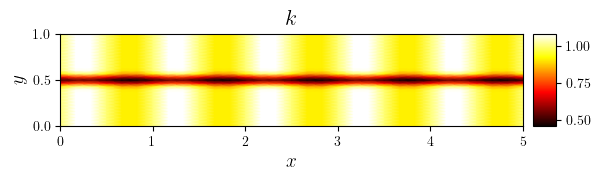

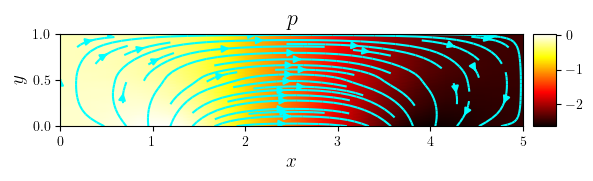

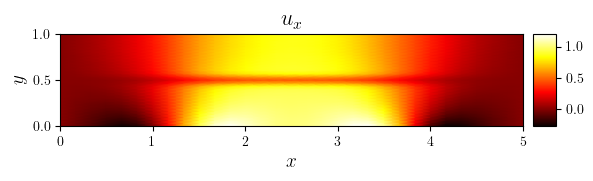

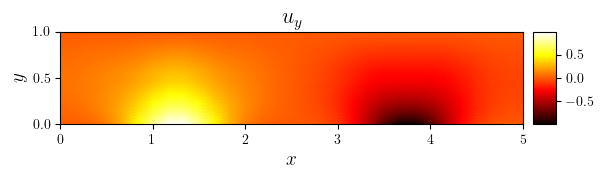

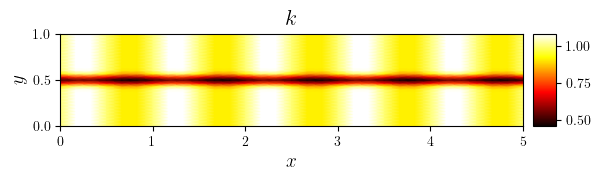

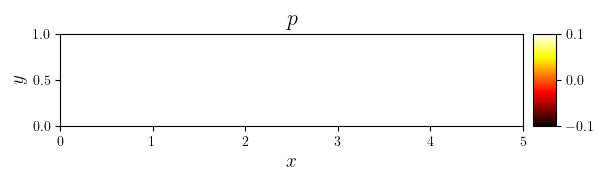

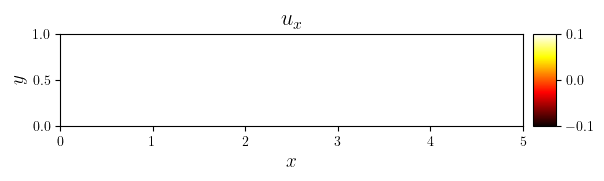

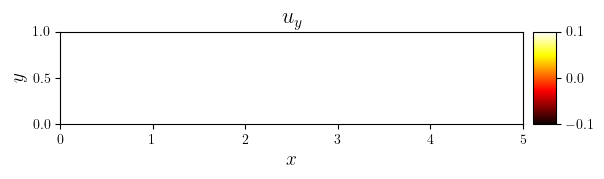

In [14]:
for up in (upMixed, upBlocked):
    u, p = up.split(collapse=True)
    ux, uy = extract_component_functions(('P', 1), u)
    fig, ax = plot_colormap(k, title='$k$', x_label='$x$', y_label='$y$')
    fig, ax = plot_colormap(p, title='$p$', x_label='$x$', y_label='$y$') 
    plot_streamlines(fig, ax, (ux, uy), density=0.75, color='cyan')
    fig, ax = plot_colormap(ux, title='$u_x$', x_label='$x$', y_label='$y$')
    fig, ax = plot_colormap(uy, title='$u_y$', x_label='$x$', y_label='$y$')

# fig, ax = plot_colormap(pBlocked, title='$p$', x_label='$x$', y_label='$y$')